# 02 Model Training
This notebook implements the training loop for the CNN architecture using the transformed pneumonia dataset.

In [9]:
import os
import torch
import bentoml
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from tqdm import tqdm
from pneumonia_classifier.ml.model.arch import Net
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score,precision_recall_fscore_support
import mlflow

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Data Loaders

In [10]:
data_dir = r'j:\Users\ayush\Desktop\code\pneumonia_classifier\artifacts\02_12_2025_08_52_04\data_ingestion\data\data'
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'test')

BATCH_SIZE = 4 
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 53
Test batches: 15


## Training Functions

In [11]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def train(model, device, train_loader, optimizer, epoch):
    model.train()
    pbar = tqdm(train_loader)
    all_preds, all_targets = [], []
    
    # Calculate global step for MLflow logging if desired
    # (assuming we want to log loss per batch across all epochs)
    batches_per_epoch = len(train_loader)
    
    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        
        # Calculate global step
        global_step = (epoch - 1) * batches_per_epoch + batch_idx
        
        # Log batch-level loss to MLflow
        mlflow.log_metric("train_batch_loss", loss.item(), step=global_step)
        
        pred = output.argmax(dim=1, keepdim=True)
        all_preds.extend(pred.cpu().numpy().flatten())
        all_targets.extend(target.cpu().numpy().flatten())
        pbar.set_description(desc=f'Train Epoch: {epoch} Loss={loss.item():.4f}')
    
    # Log the epoch-level training loss
    epoch_acc = accuracy_score(all_targets, all_preds)
    mlflow.log_metric("train_epoch_acc", epoch_acc, step=epoch)
    
    return epoch_acc
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            all_preds.extend(pred.cpu().numpy().flatten())
            all_targets.extend(target.cpu().numpy().flatten())
    
    test_loss /= len(test_loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='binary', zero_division=0)
    
    print(f'Test set: Average loss: {test_loss:.4f}, Accuracy: {100.*acc:.2f}%')
    return test_loss, acc, prec, rec

## Run Training

2026/03/03 02:02:24 INFO mlflow.tracking.fluent: Experiment with name 'cnn_model_training' does not exist. Creating a new experiment.



Starting Training...

Epoch: 1


Train Epoch: 1 Loss=0.6432: 100%|██████████| 53/53 [01:34<00:00,  1.79s/it]


Test set: Average loss: 3.2298, Accuracy: 63.16%

Epoch: 2


Train Epoch: 2 Loss=5.3999: 100%|██████████| 53/53 [01:25<00:00,  1.61s/it]


...

Test set: Average loss: 0.0637, Accuracy: 98.25%
EarlyStopping counter: 3 out of 5

Epoch: 17


Train Epoch: 17 Loss=1.9618: 100%|██████████| 53/53 [00:21<00:00,  2.42it/s]


Test set: Average loss: 0.2177, Accuracy: 91.23%
EarlyStopping counter: 4 out of 5

Epoch: 18


Train Epoch: 18 Loss=0.0516: 100%|██████████| 53/53 [00:21<00:00,  2.48it/s]


Test set: Average loss: 0.0831, Accuracy: 96.49%
EarlyStopping counter: 5 out of 5
Early stopping triggered


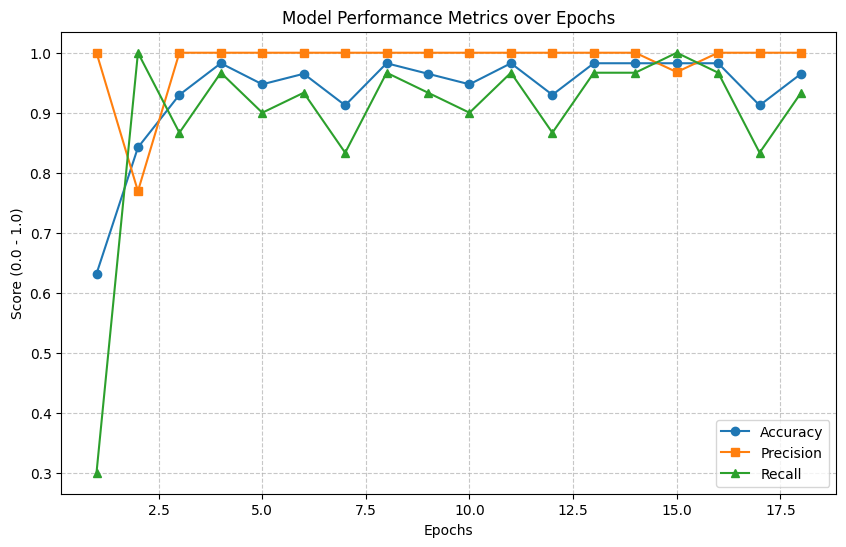

Model saved to BentoML: pneumonia_classifier_cnn:uza7heywpgthvahb


In [12]:
model = Net().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
early_stopping = EarlyStopping(patience=5)

history = {'acc': [], 'prec': [], 'rec': []}
EPOCHS = 50

# Configure MLflow
mlflow.set_experiment("cnn_model_training")
print("\nStarting Training...")

with mlflow.start_run(run_name="baseline_cnn"):
    # Log hyperparameters
    mlflow.log_params({
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": 0.01,
        "momentum": 0.9,
        "weight_decay": 1e-4
    })
    
    for epoch in range(1, EPOCHS + 1):
        print(f"\nEpoch: {epoch}")
        train_acc = train(model, device, train_loader, optimizer, epoch)
        val_loss, val_acc, val_prec, val_rec = test(model, device, test_loader)
        
        history['acc'].append(val_acc)
        history['prec'].append(val_prec)
        history['rec'].append(val_rec)
        
        # Log epoch metrics to MLflow
        mlflow.log_metrics({
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_prec": val_prec,
            "val_rec": val_rec,
            "train_acc": train_acc
        }, step=epoch)
        
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break

    # Consolidated Metrics Visualization
    plt.figure(figsize=(10, 6))
    epochs_range = range(1, len(history['acc']) + 1)
    plt.plot(epochs_range, history['acc'], label='Accuracy', marker='o')
    plt.plot(epochs_range, history['prec'], label='Precision', marker='s')
    plt.plot(epochs_range, history['rec'], label='Recall', marker='^')

    plt.title('Model Performance Metrics over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Score (0.0 - 1.0)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # Save the PyTorch model directly to BentoML
    bento_model = bentoml.pytorch.save_model(
        "pneumonia_classifier_cnn",
        model,
        signatures={
            "__call__": {"batchable": True, "batch_dim": 0}
        }
    )
    
    print(f"Model saved to BentoML: {bento_model.tag}")
    
    # Optionally log the bento model tag to the MLflow run
    mlflow.log_param("bento_model_tag", str(bento_model.tag))
